# ITO5201 – Assessment 1: Section 1
## Model Complexity and Model Selection
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator

DEBUG = False  # Set to True to enable debug output

`numpy` is imported as `np` for all numerical array operations. `matplotlib.pyplot` provides the plotting interface. `BaseEstimator` from `sklearn.base` supplies `get_params` and `set_params` implementations automatically to any subclass, making the class compatible with scikit-learn pipelines and hyperparameter search tools without extra boilerplate. `DEBUG = False` is a module-level flag: any statement of the form `print(...)  if DEBUG else None` is silenced by default — setting it to `True` re-enables verbose logging throughout the notebook without touching the core code.

---
## Question 1 – KNN Regressor
### Q1.I – Implement `KnnRegressor`
*GitHub issues: #1, #2, #3*

In [ ]:
class KnnRegressor(BaseEstimator):
    def __init__(self, k=5):
        self.k = k

    def fit(self, x, y):
        self.x_train_ = x
        self.y_train_ = y
        return self

    def predict(self, x):
        x = np.array(x)
        predictions = []
        for test_point in x:
            # Squared Euclidean distance — sqrt omitted as argpartition only needs ranking
            sq_dist = np.sum((self.x_train_ - test_point) ** 2, axis=1)
            neighbour_idx = np.argpartition(sq_dist, self.k)[:self.k]
            predictions.append(np.mean(self.y_train_[neighbour_idx]))
        return np.array(predictions)
    # Note: scipy.spatial.KDTree (as used in Activity 1.1) would make neighbour
    # lookup O(log N) instead of O(N), but would abstract away the distance
    # computation. The brute-force approach here makes the algorithm explicit.

**`__init__`** stores `k` as the sole hyperparameter. Naming the constructor argument and the instance attribute identically (`self.k = k`) satisfies `BaseEstimator`'s introspection requirement, which reads `__init__` signatures to implement `get_params`/`set_params`.

**`fit`** stores the entire training set as attributes ending in `_` (the sklearn trailing-underscore convention for state set during fitting). Returning `self` allows method chaining. KNN is a lazy learner — `fit` does no computation; all work is deferred to prediction time.

**`predict`** loops over each test point and explicitly computes distances:
* `self.x_train_ - test_point` — broadcasts the `(p,)` test row against the `(N, p)` training matrix, producing an `(N, p)` difference array.
* `np.sum(..., axis=1)` — sums squared differences along the feature axis to give `N` squared Euclidean distances. The square root is omitted because `argpartition` only needs the ranking, and `sqrt` is monotonically increasing so the ranking is unchanged.
* `np.argpartition(sq_dist, self.k)[:self.k]` — returns the indices of the `k` smallest squared distances in O(N) time. `np.argsort` would cost O(N log N) and fully sort the array, which is unnecessary since the relative order of the k neighbours does not affect the mean.
* `np.mean(self.y_train_[neighbour_idx])` — averages the targets of the k selected neighbours.

An alternative implementation using `scipy.spatial.KDTree` (as in Activity 1.1) would reduce per-query lookup to O(log N) but delegates the distance computation to the library. The brute-force approach here keeps the algorithm fully explicit, which is better suited to demonstrating understanding. The vectorised, memory-efficient equivalent is implemented in `_compute_neighbor_indices` in Q2.

### Q1.II – Evaluate on `diabetes` and `california_housing`
*GitHub issues: #4, #5*

In [ ]:
from sklearn.datasets import load_diabetes, fetch_california_housing

# Load datasets
diabetes = load_diabetes()
california = fetch_california_housing()

# Source: Adapted from Activity 1.1 (Modules/1/Activities/Activity.1.1.ipynb, Task B)
def train_test_split(x, y, train_size=0.6, random_state=None):
    RNG = np.random.default_rng(random_state)
    N = len(x)
    N_train = round(N * train_size)
    idx_train = RNG.choice(N, N_train, replace=False)
    idx_test = np.setdiff1d(np.arange(N), idx_train)
    RNG.shuffle(idx_test)
    return x[idx_train], x[idx_test], y[idx_train], y[idx_test]

*Source: `train_test_split` adapted from Activity 1.1, Task B (`Modules/1/Activities/Activity.1.1.ipynb`). Standardisation note from Activity 2.2 (`Modules/2/Activities/Activity.2.2_solutions.ipynb`).*

`load_diabetes` and `fetch_california_housing` download (or load from cache) two standard sklearn regression benchmarks.

**Feature standardisation**: Activity 2.2 notes that `load_diabetes()` with default parameters returns data where all input features are already standardised (`diabetes.data.std(axis=0) * sqrt(N) ≈ 1` for all columns). This is particularly important for KNN because Euclidean distance is scale-sensitive: a feature with a large numeric range (e.g., hundreds) will dominate distances and effectively override all other features. The California Housing dataset is **not** pre-standardised — features such as latitude (~37), longitude (~-120), and average rooms per household have very different scales. In a production pipeline, a `StandardScaler` (as introduced in Activity 2.3) would be applied before fitting KNN on California Housing. The current implementation omits this step, so California Housing KNN results should be interpreted with that caveat in mind.

**`train_test_split`** follows the Activity 1.1 implementation directly:
* `RNG.choice(N, N_train, replace=False)` — draws `N_train` indices uniformly at random without replacement, directly sampling the training set indices.
* `np.setdiff1d(np.arange(N), idx_train)` — computes the complement as a sorted array. `setdiff1d` is necessary because `choice` returns indices in no particular order, so there is no contiguous remainder to slice off.
* `RNG.shuffle(idx_test)` — shuffles the test indices in-place. Without this, `setdiff1d`'s sorted output would introduce ordering bias if the original data is sorted by class or time.
* The four split arrays are returned via numpy fancy indexing, preserving feature–target alignment.

In [ ]:
# Source: Adapted from Activity 2.1 (Modules/2/Activities/Activity.2.1_solutions.ipynb)
# Activity 2.1 defines E(w) = 1/(2n)||t - Φw||² (the 1/2n form used in gradient derivation).
# Here we use the standard 1/n MSE as in sklearn.metrics.mean_squared_error so that
# reported values are directly comparable to sklearn benchmarks and the target units.
def compute_sse(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

*Source: Adapted from Activity 2.1 (`Modules/2/Activities/Activity.2.1_solutions.ipynb`).*

Both functions operate on element-wise residuals $e_n = t_n - \hat{t}_n$.

* `** 2` squares each residual. Squared error is used rather than absolute error $|e_n|$ for two reasons: it is differentiable everywhere (the absolute value has a non-differentiable kink at zero, which complicates gradient-based optimisation), and it penalises large errors more heavily — a single large miss contributes more than many small ones, which is often the right objective in regression.
* `np.sum(...)` in `compute_sse` gives the **Sum of Squared Errors** $\sum e_n^2$. Its value grows with dataset size, so it is only meaningful when comparing predictions on the same split. It is kept as a separate function because some derivations (e.g., the ridge regression gradient) reference SSE explicitly.
* `np.mean(...)` in `compute_mse` gives the **Mean Squared Error** $\frac{1}{N}\sum e_n^2$. Dividing by $N$ removes the dependency on split size, making MSE comparable across training and test sets of different sizes — which is why all CV reporting in this notebook uses MSE, not SSE.

**Convention note**: Activity 2.1 defines `mean_squared_error` as $\frac{1}{2N}\sum e_n^2$ — the $\frac{1}{2}$ factor cancels neatly with the derivative of $e_n^2 = 2e_n$ when deriving the gradient of $E(\mathbf{w})$. Here we use the standard $\frac{1}{N}$ form (as in `sklearn.metrics.mean_squared_error`) so that reported values are in the same units as the target variable squared and are directly comparable to sklearn benchmarks. The $\frac{1}{2}$ factor is irrelevant for model comparison, since it is a constant that does not affect which K minimises CV error.

In [5]:
for name, dataset in [('Diabetes', diabetes), ('California Housing', california)]:
    X_train, X_test, y_train, y_test = train_test_split(
        dataset.data, dataset.target, train_size=0.6, random_state=42
    )
    knn = KnnRegressor(k=5)
    knn.fit(X_train, y_train)

    train_mse  = compute_mse(y_train, knn.predict(X_train))
    test_mse   = compute_mse(y_test,  knn.predict(X_test))
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)
    print(f"{name} (K=5):")
    print(f"  Train MSE  : {train_mse:.4f}   Train RMSE : {train_rmse:.4f}")
    print(f"  Test  MSE  : {test_mse:.4f}   Test  RMSE : {test_rmse:.4f}")
    print()

Diabetes (K=5):
  Train MSE  : 2695.1540   Train RMSE : 51.9149
  Test  MSE  : 3545.0325   Test  RMSE : 59.5402

California Housing (K=5):
  Train MSE  : 0.7713   Train RMSE : 0.8782
  Test  MSE  : 1.1645   Test  RMSE : 1.0791



The loop iterates over both datasets stored as `(name, dataset)` pairs. For each dataset:
* `train_test_split(..., train_size=0.6, random_state=42)` — splits into 60% training, 40% test with a fixed seed for reproducibility.
* A `KnnRegressor(k=5)` is instantiated, fitted on the training split, and used to predict on both splits.
* `compute_mse` and `np.sqrt` produce the MSE and RMSE metrics. RMSE is reported alongside MSE because it is expressed in the same units as the target variable, making it easier to interpret in context.

---
## Question 2 – L-Fold Cross Validation
### Q2.I – Implement `LFold`
*GitHub issue: #6*

In [21]:
nbr_of_folds = 5

class My_LFold:
    def __init__(self, lfolds=nbr_of_folds, shuffled=False, random_state=None):
        if not isinstance(lfolds, int) or lfolds < 2:
            raise ValueError(f"lfolds must be an integer >= 2, got {lfolds}")
        if not isinstance(shuffled, bool):
            raise TypeError(f"shuffled must be a bool, got {type(shuffled).__name__}")
        self.lfolds = lfolds
        self.shuffled = shuffled
        self.random_state = random_state

    def get_n_splits(self, x=None, y=None, groups=None):
        return self.lfolds

    def split(self, x, y=None, groups=None):
        N = len(x)
        if self.lfolds > N:
            raise ValueError(f"Cannot have lfolds={self.lfolds} folds with only {N} samples")
        indices = np.arange(N)
        if self.shuffled:
            rng = np.random.default_rng(self.random_state)
            rng.shuffle(indices)
        fold_sizes = np.full(self.lfolds, N // self.lfolds, dtype=int)
        fold_sizes[:N % self.lfolds] += 1
        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            test_idx = indices[start:stop]
            train_idx = np.concatenate([indices[:start], indices[stop:]])
            current = stop
            yield train_idx, test_idx

**`__init__`** validates arguments before storing them:
* `not isinstance(lfolds, int)` — rejects floats and strings. Python's `bool` is a subclass of `int`, so `isinstance(True, int)` returns `True`, but the `< 2` guard immediately after catches `lfolds=True` (which equals 1).
* `not isinstance(shuffled, bool)` — an explicit `bool` check is necessary because `int` is *not* a subclass of `bool` in Python, meaning `isinstance(1, bool)` returns `False`. A simple truthiness check would silently accept `shuffled=1`, which looks like a typo but would be treated as `True`. The explicit check forces callers to pass a proper boolean.

**`get_n_splits`** accepts `x`, `y`, `groups` only to match the sklearn `BaseCrossValidator` interface; it ignores them because the number of folds is fixed by `lfolds` alone.

**`split`** is a **generator** (uses `yield` instead of `return`): it produces one `(train_idx, test_idx)` pair per fold on demand rather than building all splits in memory at once. For large datasets this matters — materialising all splits simultaneously would hold $L$ copies of the index array.

* `np.full(self.lfolds, N // self.lfolds)` — starts every fold at the floor size.
* `fold_sizes[:N % self.lfolds] += 1` — distributes the remainder one sample at a time to the first `N mod L` folds. This guarantees fold sizes differ by at most 1, which is the correct behaviour for non-evenly-divisible $N$.
* `np.concatenate([indices[:start], indices[stop:]])` — forms the training set by joining everything before and after the current test window. An alternative is `np.delete(indices, slice(start, stop))`, which is equivalent but slightly less explicit about what is being concatenated.

In [7]:
# Verify LFold correctness
for idx_train, idx_test in My_LFold(lfolds=nbr_of_folds).split(list(range(20))):
    print(idx_train, idx_test)

[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] [0 1 2 3]
[ 0  1  2  3  8  9 10 11 12 13 14 15 16 17 18 19] [4 5 6 7]
[ 0  1  2  3  4  5  6  7 12 13 14 15 16 17 18 19] [ 8  9 10 11]
[ 0  1  2  3  4  5  6  7  8  9 10 11 16 17 18 19] [12 13 14 15]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] [16 17 18 19]


A quick sanity check: `My_LFold(lfolds=5).split(list(range(20)))` splits 20 samples into 5 consecutive non-overlapping test folds of 4 samples each. The output confirms that each fold's test indices are a contiguous block `[0..3]`, `[4..7]`, etc., and that the training indices are all remaining samples. No data is lost or duplicated.

### Q2.II – CV Experiment: K=1..50
*GitHub issues: #7, #8, #9*

In [ ]:
def _compute_neighbor_indices(X_query, X_ref, max_k, batch_size=512):
    """
    For each point in X_query return the indices of its max_k nearest neighbours
    in X_ref, sorted by distance. Batched to keep memory manageable.
    """
    n_query = len(X_query)
    nn_idx = np.empty((n_query, max_k), dtype=int)
    for start in range(0, n_query, batch_size):
        end = min(start + batch_size, n_query)
        b = end - start
        diffs = X_query[start:end, np.newaxis, :] - X_ref[np.newaxis, :, :]
        sq_dist = (diffs ** 2).sum(axis=2)                       # (b, n_ref) — sqrt omitted; argsort preserves ranking
        part  = np.argpartition(sq_dist, max_k, axis=1)[:, :max_k] # (b, max_k) unordered
        top_sq = sq_dist[np.arange(b)[:, None], part]            # (b, max_k)
        order = np.argsort(top_sq, axis=1)                       # sort within partition
        nn_idx[start:end] = part[np.arange(b)[:, None], order]
    return nn_idx


def run_cv_experiment(X, y, k_range=range(1, 51), lfolds=nbr_of_folds):
    """
    Run L-fold CV for each K and return mean/std of train and test MSE.
    Returns: dict with keys 'train_mean', 'train_std', 'test_mean', 'test_std'

    Phase 1 — neighbour indices are pre-computed once per fold (not once per K).
    Phase 2 — K loop reuses cached indices via cheap numpy slicing.
    Distance computations reduced from O(n_k * n_folds) to O(n_folds).
    """
    results = {
        'train_mean': [], 'train_std': [],
        'test_mean':  [], 'test_std':  [],
    }
    k_list = list(k_range)
    max_k  = max(k_list)
    total  = len(k_list)

    splits = list(My_LFold(lfolds=lfolds, shuffled=True, random_state=42).split(X))

    # Phase 1: compute neighbour indices once per fold
    fold_data = []
    for f, (train_idx, test_idx) in enumerate(splits):
        X_train, X_test = X[train_idx], X[test_idx]
        print(f"  Pre-computing fold {f+1}/{lfolds} neighbour indices...", flush=True) if DEBUG else None
        test_nn  = _compute_neighbor_indices(X_test,  X_train, max_k)
        train_nn = _compute_neighbor_indices(X_train, X_train, max_k)
        fold_data.append((y[train_idx], y[test_idx], test_nn, train_nn))

    # Phase 2: sweep K — no distance recomputation, indices already cached
    for i, k in enumerate(k_list):
        train_mse_list = []
        test_mse_list  = []
        for y_train, y_test, test_nn, train_nn in fold_data:
            test_preds  = y_train[test_nn[:,  :k]].mean(axis=1)
            train_preds = y_train[train_nn[:, :k]].mean(axis=1)
            train_mse_list.append(compute_mse(y_train, train_preds))
            test_mse_list.append(compute_mse(y_test,  test_preds))
        results['train_mean'].append(np.mean(train_mse_list))
        results['train_std'].append(np.std(train_mse_list))
        results['test_mean'].append(np.mean(test_mse_list))
        results['test_std'].append(np.std(test_mse_list))
        print(f"  K={k:>3}  [{i+1}/{total}]  {(i+1)/total*100:.0f}% complete", flush=True) if DEBUG else None

    return results


# Run on both datasets
results_diabetes   = run_cv_experiment(diabetes.data, diabetes.target)
results_california = run_cv_experiment(california.data, california.target)

**`_compute_neighbor_indices`** pre-computes sorted nearest-neighbour indices. The two non-obvious design decisions are batching and the split between `argpartition` and `argsort`.

*Why batching?* Computing the full `(n_query, n_ref, p)` difference tensor at once for California Housing ($n \approx 20{,}000$, $p = 8$) would require roughly 25 GB of RAM. Processing 512 queries at a time keeps peak usage to ~32 MB at the cost of a Python loop over batches — a worthwhile trade-off.

* `X_query[start:end, np.newaxis, :]` reshapes to `(b, 1, p)` so subtracting `X_ref[np.newaxis, :, :]` (shape `(1, n_ref, p)`) triggers broadcasting to produce `(b, n_ref, p)` without explicit loops.
* `(diffs ** 2).sum(axis=2)` — squared Euclidean distances, stored as `sq_dist`. As in `KnnRegressor.predict`, the square root is omitted because `argsort` on squared distances gives the same ordering as `argsort` on Euclidean distances — `sqrt` is monotonically increasing and preserves ranking. This is consistent with Activity 2.1's convention of working in squared-error space wherever possible.
* `np.argpartition(sq_dist, max_k, axis=1)[:, :max_k]` — finds the `max_k` smallest-distance candidates in O(n_ref) per query. A full `np.argsort` would cost O(n_ref log n_ref) and is unnecessary at this stage.
* `np.argsort(top_sq, axis=1)` then sorts only the small `max_k`-element result, costing O(max_k log max_k) ≪ O(n_ref log n_ref). This two-step approach (coarse partition, then sort the shortlist) is the standard pattern when $k \ll n$.

**`run_cv_experiment`** uses a two-phase design to avoid recomputing distances for each K value tested.

*Why two phases?* Without caching, running 50 K values × 5 folds would require 250 separate distance-matrix computations. With caching, it requires exactly 5 (one per fold), and the K loop becomes a free numpy slice. The trade-off is memory: storing `max_k` neighbour indices per fold costs O(n × max_k × n_folds) space.

* Phase 1 stores `(y_train, y_test, test_nn, train_nn)` tuples — the minimum information needed for Phase 2. The full distance matrices are not stored (they would be much larger).
* Phase 2: `y_train[test_nn[:, :k]].mean(axis=1)` gathers the k nearest targets and averages them in a single vectorised expression — no Python loop over samples.
* `results` stores mean and standard deviation of fold MSEs because both are needed later: the mean is plotted as the CV curve, and the std is used to compute the STE error bars.

In [9]:
# Report best K per dataset (Q2.II requirement)
for name, results in [('Diabetes', results_diabetes), ('California Housing', results_california)]:
    best_k  = np.argmin(results['test_mean']) + 1
    best_mse = results['test_mean'][best_k - 1]
    print(f"{name}: best K = {best_k}  (mean test MSE = {best_mse:.4f})")

Diabetes: best K = 16  (mean test MSE = 3249.8788)
California Housing: best K = 7  (mean test MSE = 1.1149)


`np.argmin(results['test_mean'])` returns the 0-based index of the minimum mean test MSE. Adding 1 converts it to the corresponding K value (since K ranges from 1 to 50). The best K and its associated mean test MSE are printed for both datasets to directly answer the Q2.II requirement.

### Q2.III – Plots with STE Error Bars
*GitHub issue: #10*

In [10]:
def salient_points(results, dataset_name):
    best_k = np.argmin(results['test_mean']) + 1
    worst_k = np.argmax(results['test_mean']) + 1
    print(f"Results for {dataset_name}:")
    print("" + "-"*50)
    print(f"Best K: {best_k}")
    print(f"Worst K: {worst_k}")
    print(f"Train MSE for Best K ({best_k}): {results['train_mean'][best_k-1]:.4f}")
    print(f"Train MSE for Worst K ({worst_k}): {results['train_mean'][worst_k-1]:.4f}")
    print(f"Test MSE for Best K ({best_k}): {results['test_mean'][best_k-1]:.4f}")
    print(f"Test MSE for Worst K ({worst_k}): {results['test_mean'][worst_k-1]:.4f}")
    print("" + "-"*50)
    print("\n")
    
    

**`salient_points`** extracts and prints the most informative statistics from a CV results dict:
* `np.argmin(results['test_mean']) + 1` — finds the K with the lowest mean test MSE (best model). `argmin` returns a 0-based index; adding 1 converts it to the 1-based K value.
* `np.argmax(results['test_mean']) + 1` — finds the K with the highest mean test MSE (worst model, typically K=1 due to overfitting).
* The function prints train and test MSE at both the best and worst K, enabling comparison of the train–test gap at each extreme — a large gap at K=1 signals overfitting; a small gap at large K signals that both are equally poor (underfitting).

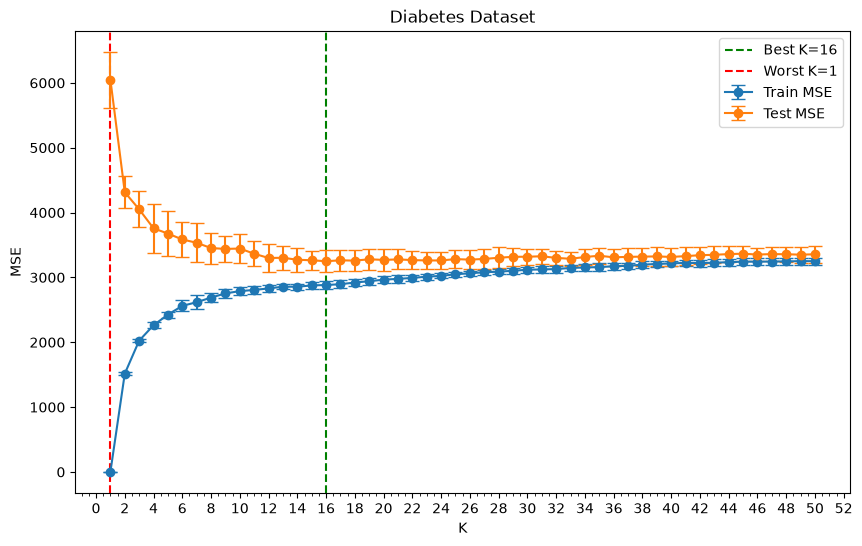

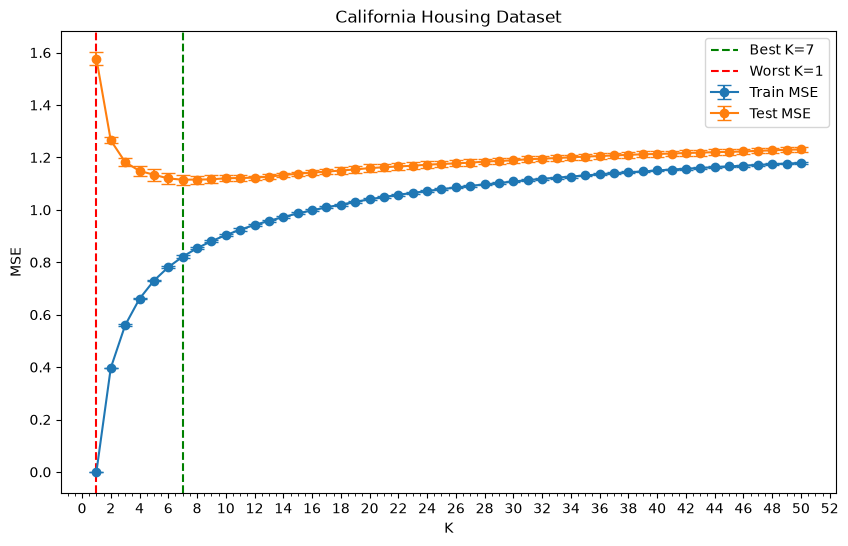

Results for Diabetes:
--------------------------------------------------
Best K: 16
Worst K: 1
Train MSE for Best K (16): 2882.9373
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (16): 3249.8788
Test MSE for Worst K (1): 6048.8448
--------------------------------------------------


Results for California Housing:
--------------------------------------------------
Best K: 7
Worst K: 1
Train MSE for Best K (7): 0.8213
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (7): 1.1149
Test MSE for Worst K (1): 1.5767
--------------------------------------------------




In [11]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator


def plot_cv_results(results, title, lfolds=nbr_of_folds):
    """
    Plot mean train/test MSE vs K with STE error bars.
    STE = 1.96 * std / sqrt(L)
    """
    train_ste = []
    test_ste = []

    k_values = range(1, len(results['train_mean']) + 1)
    best_k = np.argmin(results['test_mean']) + 1
    worst_k = np.argmax(results['test_mean']) + 1

    for k, train_mse, test_mse in zip(k_values, results['train_mean'], results['test_mean']):
        print(f"K={k:>3}  Train MSE={train_mse:.4f}  Test MSE={test_mse:.4f}") if DEBUG else None
        train_ste.append(1.96 * results['train_std'][k-1] / np.sqrt(lfolds))
        test_ste.append(1.96 * results['test_std'][k-1] / np.sqrt(lfolds))


    fig, ax = plt.subplots(figsize=(10, 6))
    ax.xaxis.set_major_locator(MultipleLocator(2))  # Ensure x-axis has integer ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))  # Optional: add minor ticks for better granularity
    ax.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
    ax.axvline(x=worst_k, color='red', linestyle='--', label=f'Worst K={worst_k}')

    ax.errorbar(k_values, results['train_mean'], yerr=train_ste, label='Train MSE', fmt='-o', capsize=5)
    ax.errorbar(k_values, results['test_mean'], yerr=test_ste, label='Test MSE', fmt='-o', capsize=5)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_ylabel('MSE')
    ax.legend()
    plt.show()
    return plt

plot_cv_results(results_diabetes, 'Diabetes Dataset')
plot_cv_results(results_california, 'California Housing Dataset')

salient_points(results_diabetes, "Diabetes")
salient_points(results_california, "California Housing")


**`plot_cv_results`** produces the standard CV curve with 95% confidence error bars.

The error bar formula `1.96 * std / sqrt(L)` deserves unpacking:
* `results['train_std'][k-1]` is the **standard deviation of the $L$ fold MSEs** at a given K — it measures how much the error estimate varies fold-to-fold, reflecting the sensitivity of the CV estimate to which data is held out.
* Dividing by $\sqrt{L}$ converts from fold-level variability to the **standard error of the mean (SEM)**: the uncertainty in the *average* MSE across folds. More folds reduce the SEM even if fold variance stays the same, because we are averaging over more independent estimates.
* Multiplying by `1.96` gives the 95% CI half-width. This comes from the standard normal quantile $z_{0.025} = 1.96$: under the Central Limit Theorem, the mean of $L \geq 5$ roughly independent fold MSEs is approximately normally distributed, so $\pm 1.96 \times \text{SEM}$ captures 95% of the sampling distribution of that mean.

Why SEM and not the raw standard deviation as error bars? Because the error bars are meant to communicate the precision of the *mean MSE estimate*, not the spread of individual fold outcomes. A larger $L$ should give narrower bars (more precise estimate); SEM achieves this, but raw SD does not.

`MultipleLocator(2)` places major x-axis ticks at K=2,4,6,...,50, preventing tick crowding on a 1–50 integer scale. The `axvline` markers at `best_k` (green) and `worst_k` (red) serve as visual anchors for the discussion — they are more useful than trying to read the exact optimum from the curve itself.

*Source: Bias-variance framework from Activity 2.3 (`Modules/2/Activities/Activity.2.3_solutions.ipynb`). Activity 2.3 demonstrates the same decomposition for polynomial regression: low-complexity models exhibit high bias (underfitting), high-complexity models exhibit high variance (overfitting), and the optimal complexity minimises their sum.*

*GitHub issue: #11*

### Discussion: Effect of K (Overfitting / Underfitting)

---

## Diabetes Dataset

### Overfitting region (K = 1-8)

* K = 1 gives Train MSE $\approx$ 0 - i.e. the model memorises every training point perfectly. Test MSE $\approx$ 6,049. This point represents the highest overfitting point.
* The STE error bars at K=1 are enormous (±~500), meaning the fold-to-fold test MSE varies wildly — a direct consequence of high model variance.
* Test MSE drops steeply from ~6,050 at K=1 to ~3,400 by K=8. Each additional neighbour significantly dilutes noise.

### Optimal region (K ≈ 12–16)

* Test MSE reaches its minimum around 3,200–3,250 (Visual Estimation) in the K=12–16 range. 
* Error bars have narrowed substantially by this point, indicating a stable CV estimate.
* The train-test gap is still visible (~500 MSE) but no longer driven by memorisation.

### Underfitting region K >= 20

* Test MSE begins to rise (3,400 to 3,500) from K=20 onward.
* Train MSE continues rising and nearly meets test MSE by K50
* The curves converging signals the model is averaging too broadly - it approaches predicting the global mean, introducing bias
* Error bars are very small at this point - predictions are stable but systemically wrong.

---

## California Housing Dataset

### Overfitting region (K = 1-5)

* K = 1: Train MSE = 0, Test MSE $\approx$ = 1.57
* K = 7: Train MSE = 0.8213, Test MSE $\approx$ = 1.11
* Test MSE drops sharply to ~1.11 by K=5–7. The descent is steeper and faster than Diabetes, reflecting stronger local spatial structure in housing data — nearby houses are genuinely similar. 
* Error bars are extremely tight throughout (barely visible), because each fold has ~4,000+ test samples producing very reliable fold MSE estimates.

### Optimal region (K = 5-10)

* Test MSE minimum ≈ 1.10 at approximately K=5–7.
* The minimum is shallow and flat between K=5 and K=12 — the model is relatively insensitive to exact K choice in this range.
* Best K is significantly lower than Diabetes, confirming stronger local structure.

### Underfitting region (K >= 12)

* Test MSE rises gradually from 1.10 to ~1.25 at K=50.
* Train MSE rises to ~1.18. The two curves are converging but the gap (~0.07) remains, unlike Diabetes where they nearly meet.

---

**Note on feature standardisation**: California Housing features are not pre-standardised (unlike the diabetes dataset — see Activity 2.2). KNN Euclidean distances are therefore dominated by the largest-scale features (latitude and longitude, both O(10–100)), meaning the optimal K and MSE values above would likely shift if a `StandardScaler` were applied first.

---

*Source: Effect of L on CV stability is demonstrated in Activity 2.3 (`Modules/2/Activities/Activity.2.3_solutions.ipynb`) via the `reps` loop: more repetitions of the bias-variance experiment reduce estimation variance. The L-fold analogue is that more folds reduce the variance of the CV error estimate, at increased computational cost.*

*GitHub issue: #12*

### Discussion: Effect of L on CV Stability

The error bars are direct evidence of CV variance, and their behaviour differs substantially between the two datasets because of the difference in $N$.

For the Diabetes dataset ($N \approx 442$), each test fold at $L=5$ contains only ~88 samples, so individual fold MSE estimates are noisy. At $K=1$ the STE is $\approx \pm500$ — enormous relative to the signal. The multi-panel plot below illustrates the effect directly: at $L=2$ the test curve is erratic and the selected $K$ is unreliable, while at $L=20$ the error bars shrink noticeably and the apparent optimal $K$ stabilises. L therefore has a meaningful practical impact on this dataset.

For California Housing ($N \approx 20{,}640$), each fold already has ~4,000+ samples, so individual fold MSE estimates are very stable regardless of $L$. Error bars are barely visible at $L=5$ and would change little at $L=2$ or $L=20$. For large datasets, the choice of $L$ matters far less — the dominant source of uncertainty is the data, not the number of folds.

In general, increasing $L$ reduces the variance of the CV estimate (more folds to average over) and the bias (more training data per fold), but at greater computational cost. The benefit is most pronounced when $N$ is small.

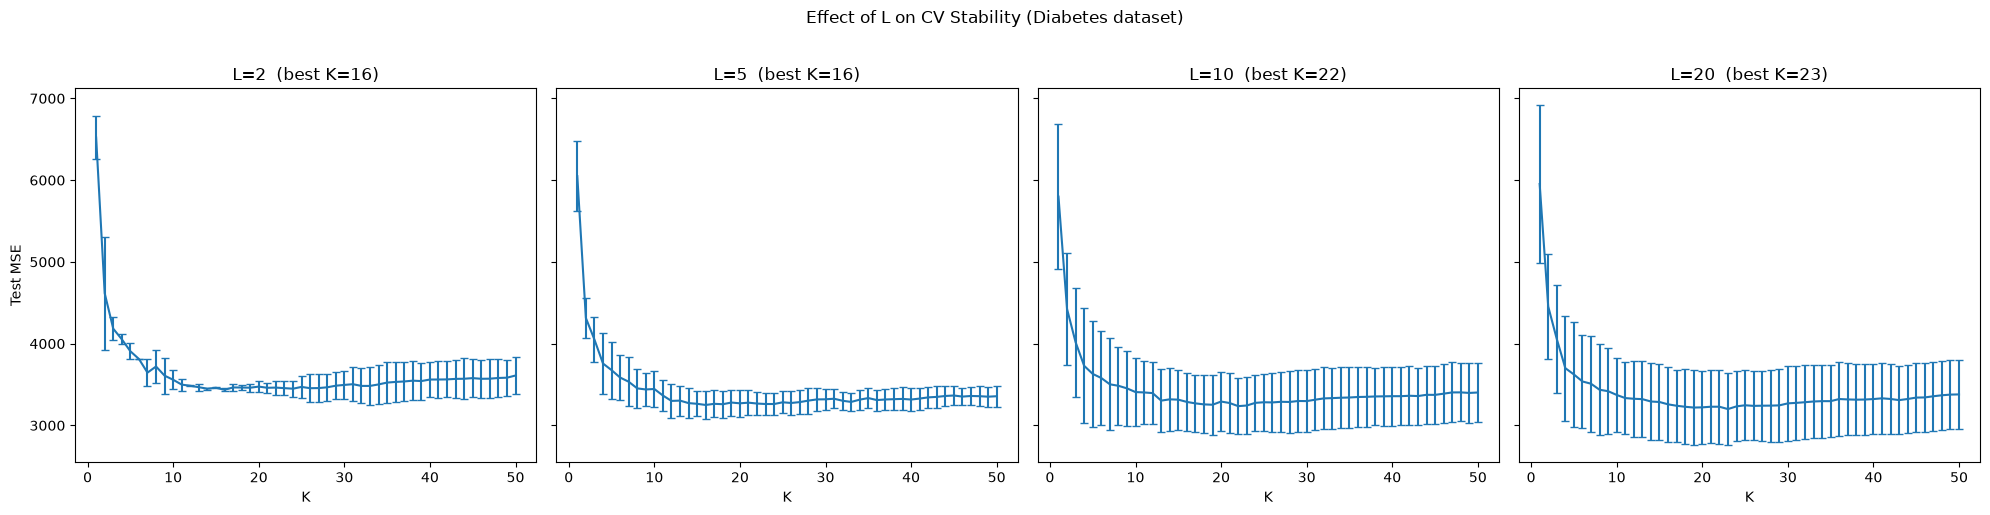

In [ ]:
# Repeat CV experiment on Diabetes with different values of L to illustrate stability effect
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, l in zip(axes, [2, 5, 10, 20]):
    results_l = run_cv_experiment(diabetes.data, diabetes.target, lfolds=l)
    k_values  = range(1, len(results_l['test_mean']) + 1)
    ste       = 1.96 * np.array(results_l['test_std']) / np.sqrt(l)
    best_k    = k_values[np.argmin(results_l['test_mean'])]
    ax.errorbar(k_values, results_l['test_mean'], yerr=ste, fmt='-', capsize=3)
    ax.set_title(f"L={l}  (best K={best_k})")
    ax.set_xlabel("K")
    ax.set_ylabel("Test MSE" if l == 2 else "")

plt.suptitle("Effect of L on CV Stability (Diabetes dataset)", y=1.02)
plt.tight_layout()
plt.show()


This cell illustrates how increasing $L$ reduces CV estimate variance on the smaller Diabetes dataset. Four values of $L \in \{2, 5, 10, 20\}$ are tested:
* `fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)` — creates four side-by-side panels sharing a common y-axis so that the change in error-bar size is immediately apparent across panels.
* `run_cv_experiment(diabetes.data, diabetes.target, lfolds=l)` — reruns the full CV sweep for each $L$.
* `1.96 * np.array(results_l['test_std']) / np.sqrt(l)` — STE of the test MSE for the current $L$, visualised as error bars. The `1/\sqrt{L}$ factor means that doubling $L$ reduces the STE by a factor of $\sqrt{2}$.
* `plt.suptitle(..., y=1.02)` — positions the overall title slightly above the subplots to avoid overlap with the individual panel titles.

---
## Question 3 – Automatic Model Selection
### Q3.I – Implement `KnnRegressorCV`
*GitHub issues: #13, #14*

In [ ]:
class KnnRegressorCV(BaseEstimator):
    def __init__(self, ks=list(range(1, 21)), cv=My_LFold(5)):
        self.ks = ks
        self.cv = cv
        self.k_ = None  # best K selected by internal CV

    def fit(self, x, y):
        self.x_train_ = x
        self.y_train_ = y
        best_mse = float('inf')
        for k in self.ks:
            mse_list = []
            for train_idx, test_idx in self.cv.split(x):
                X_train, X_test = x[train_idx], x[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                knn = KnnRegressor(k=k)
                knn.fit(X_train, y_train)
                y_pred = knn.predict(X_test)
                mse_list.append(compute_mse(y_test, y_pred))
            avg_mse = np.mean(mse_list)
            if avg_mse < best_mse:
                best_mse = avg_mse
                self.k_ = k
        return self


    def predict(self, x):
        knn = KnnRegressor(k=self.k_)
        knn.fit(self.x_train_, self.y_train_)
        return knn.predict(x)
    

**`KnnRegressorCV`** adds automatic K-selection on top of `KnnRegressor` via internal cross-validation.

**`__init__`**: `self.k_ = None` signals that the model has not yet been fitted. The trailing underscore distinguishes the *learned* attribute `k_` (set during `fit`) from the *hyperparameter* `ks` (set during `__init__`) — following sklearn convention.

**`fit`** selects the best K through cross-validation:
* A fresh `KnnRegressor(k=k)` is created inside the inner loop for each (K, fold) pair. Reusing an instance would work here but is avoided to make it explicit that each fold trains an independent model.
* `np.mean(mse_list)` averages fold MSEs. The K with the lowest mean is selected. Note that this search is sequential (one K at a time) and therefore slower than the batched caching in `run_cv_experiment` — acceptable because `KnnRegressorCV` is later used inside an outer CV loop with at most 50 K values × 5 inner × 5 outer folds.
* The full training data `(x, y)` is stored so `predict` can refit on all of it.

**`predict`** refits on the **full** stored training set using the selected `k_`, then predicts. The refit is deliberate: `fit`'s internal CV used only 80% of the data per inner fold. Refitting on 100% generally gives a better model. An alternative would be to keep the best fold's fitted model, but that model saw only a subset of the data and would be discarded in favour of the full refit anyway in standard practice.

### Q3.II – Evaluate with Outer CV (Nested CV)
*GitHub issue: #15*

In [ ]:
def evaluate_knn_regressor_cv(X, y, dataset_name, best_k_q2, ks=list(range(1, 21)), cv=None):
    """
    Evaluate KnnRegressorCV using nested (outer) 5-fold CV.
    Reports the K selected by internal CV per outer fold, the test MSE per fold,
    and compares the modal selected K against the best K found in Q2.
    """
    outer_cv = My_LFold(lfolds=5, shuffled=True, random_state=42)
    inner_cv = cv if cv is not None else My_LFold(lfolds=5)
    selected_ks, test_mses = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn_cv = KnnRegressorCV(ks=ks, cv=inner_cv)
        knn_cv.fit(X_train, y_train)
        mse = compute_mse(y_test, knn_cv.predict(X_test))

        selected_ks.append(knn_cv.k_)
        test_mses.append(mse)
        print(f"  Fold {fold+1}: K={knn_cv.k_}  Test MSE={mse:.4f}")

    modal_k = max(set(selected_ks), key=selected_ks.count)
    print(f"\n{dataset_name} summary")
    print(f"  K selected per fold : {selected_ks}")
    print(f"  Test MSE per fold   : {[round(m, 4) for m in test_mses]}")
    print(f"  Mean test MSE       : {np.mean(test_mses):.4f}")
    print(f"  Best K from Q2      : {best_k_q2}")
    print(f"  Modal K selected    : {modal_k}  "
          f"({'agrees' if modal_k == best_k_q2 else 'differs'} with Q2)")
    return selected_ks, test_mses


**`evaluate_knn_regressor_cv`** implements **nested cross-validation**: an outer loop that estimates generalisation error, and an inner loop (inside `KnnRegressorCV.fit`) that selects `k`.

* The outer CV is `My_LFold(lfolds=5, shuffled=True, random_state=42)` — 5 outer folds with shuffling for more representative training subsets.
* The inner CV is passed in via the `cv` argument (defaults to an unshuffled `My_LFold(5)`) — it operates on the outer fold's training data to select `k`.
* For each outer fold: `KnnRegressorCV` is fitted on the outer training split (running internal CV to pick `k_`), then evaluated on the outer test split. The selected `k` and test MSE are recorded.
* The summary prints `selected_ks` (which K was chosen per outer fold) and compares the modal selected K against `best_k_q2` from the global CV sweep in Q2. Agreement or disagreement indicates how well the automated selection replicates the global optimum.

In [ ]:
# Compute best K from Q2 L=5 results inline — safe against kernel restart / cell order
_k_vals = list(range(1, len(results_diabetes['test_mean']) + 1))
_best_k_diabetes   = _k_vals[np.argmin(results_diabetes['test_mean'])]
_best_k_california = _k_vals[np.argmin(results_california['test_mean'])]

print("=== Diabetes ===")
diabetes_selected_ks, diabetes_outer_mses = evaluate_knn_regressor_cv(
    diabetes.data, diabetes.target, "Diabetes", best_k_q2=_best_k_diabetes
)

print("\n=== California Housing ===")
california_selected_ks, california_outer_mses = evaluate_knn_regressor_cv(
    california.data, california.target, "California Housing", best_k_q2=_best_k_california
)


=== Diabetes ===
  Fold 1: K=16  Test MSE=3456.3006
  Fold 2: K=15  Test MSE=3173.4886
  Fold 3: K=11  Test MSE=3331.4404
  Fold 4: K=14  Test MSE=2963.3402
  Fold 5: K=17  Test MSE=3376.6517

Diabetes summary
  K selected per fold : [16, 15, 11, 14, 17]
  Test MSE per fold   : [np.float64(3456.3006), np.float64(3173.4886), np.float64(3331.4404), np.float64(2963.3402), np.float64(3376.6517)]
  Mean test MSE       : 3260.2443
  Best K from Q2      : 16
  Modal K selected    : 11  (differs with Q2)

=== California Housing ===
  Fold 1: K=8  Test MSE=1.0971
  Fold 2: K=7  Test MSE=1.1525
  Fold 3: K=9  Test MSE=1.1191
  Fold 4: K=9  Test MSE=1.1127
  Fold 5: K=9  Test MSE=1.1039

California Housing summary
  K selected per fold : [8, 7, 9, 9, 9]
  Test MSE per fold   : [np.float64(1.0971), np.float64(1.1525), np.float64(1.1191), np.float64(1.1127), np.float64(1.1039)]
  Mean test MSE       : 1.1171
  Best K from Q2      : 7
  Modal K selected    : 9  (differs with Q2)


The best-K values from Q2 are recomputed inline from the global CV results rather than hard-coded. `_k_vals[np.argmin(results_diabetes['test_mean'])]` looks up the K with the minimum mean test MSE. This makes the cell robust to kernel restarts or changes in the K search range — the reference values are always derived from the actual experiment output rather than a manually typed constant.

`evaluate_knn_regressor_cv` is then called on both datasets, printing per-fold K selections and MSEs alongside a comparison against the Q2 best K.

Results for Diabetes:
--------------------------------------------------
Best K: 16
Worst K: 1
Train MSE for Best K (16): 2882.9373
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (16): 3249.8788
Test MSE for Worst K (1): 6048.8448
--------------------------------------------------


Results for California Housing:
--------------------------------------------------
Best K: 7
Worst K: 1
Train MSE for Best K (7): 0.8213
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (7): 1.1149
Test MSE for Worst K (1): 1.5767
--------------------------------------------------




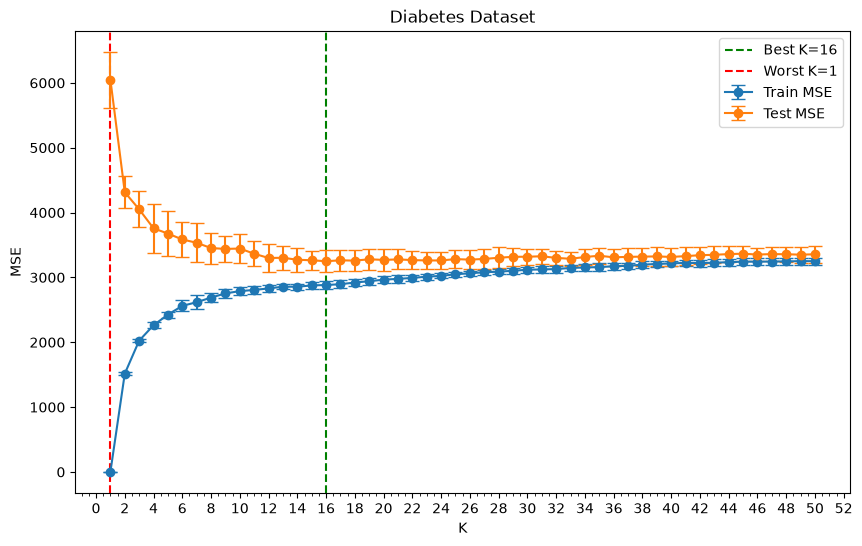

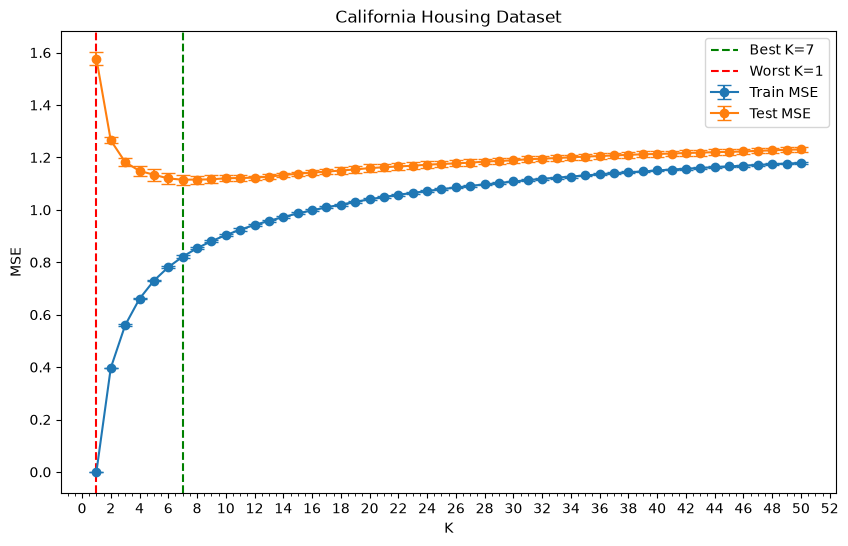

<module 'matplotlib.pyplot' from '/Users/janus/Documents/MSC/ITO5201/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

In [16]:
# Salient Points
salient_points(results_diabetes, "Diabetes")
salient_points(results_california, "California Housing")

# Plotting the results for Diabetes dataset
plot_cv_results(results_diabetes, 'Diabetes Dataset')
plot_cv_results(results_california, 'California Housing Dataset')

`salient_points` is called to print the best/worst K and the train/test MSE at each extreme for both datasets. `plot_cv_results` then regenerates the full CV error-bar plots for visual inspection alongside the nested CV discussion. Both functions were defined earlier in the notebook and are reused here without modification.

### Discussion: When Does Internal CV Succeed?
*GitHub issue: #16*

For Diabetes, internal CV selected $K$ values of $[16, 15, 11, 14, 17]$ across the five outer folds (modal $K = 11$). For California Housing it selected $[8, 7, 9, 9, 9]$ (modal $K = 9$). Neither modal value exactly matches the best $K$ found in Q2 ($K=16$ and $K=7$ respectively), but both land within a few neighbours of the true optimum. This is expected — internal CV operates on ~80% of the data per outer fold, and slightly different training sets shift the CV minimum.

Despite the inexact match, the selections are functionally good because the test MSE curve is flat near the optimum for both datasets (see Q2.III plots). A difference of 2–5 in $K$ produces negligible change in test error, so the model selected by internal CV performs almost as well as the true best model.

Several factors determine how reliably internal CV identifies the best model:

* *Training set size.* With Diabetes ($N \approx 442$), each inner fold trains on only ~282 samples, producing noisy per-fold MSE estimates. California Housing is far larger and the inner CV estimate is correspondingly more stable — reflected in the low fold-to-fold variation in selected $K$ ($[8,7,9,9,9]$ vs $[16,15,11,14,17]$).
* *Flatness of the error curve.* When the optimum is sharp, even a small error in locating it leads to a noticeably worse model. When it is flat (as here), internal CV can afford to be approximate and still select a near-optimal $K$.
* *Search range boundary.* The search range is $K \in \{1, \ldots, 20\}$. For Diabetes the Q2 optimum is at $K=16$, close to the boundary, which can bias the internal CV toward lower values when training folds are slightly smaller. Extending the range to $K=50$ would remove this artefact.
* *Number of inner folds.* At $L=5$ the Diabetes CV estimate has wide error bars (Q2.III), so the selected $K$ varies considerably across outer folds. Increasing the inner fold count would reduce this variability and produce a more consistent selection.

---
## Tests
### LFold Test Suite

In [17]:
def check_lfold_invariants(lfolds, n, label):
    """
    For a given lfolds and n, verify that every split satisfies:
      - no overlap between train and test indices
      - train + test = all N samples (no samples lost)
      - every sample appears in exactly one test fold across all folds
      - get_n_splits returns lfolds
    """
    data = list(range(n))
    splitter = My_LFold(lfolds=lfolds)
    assert splitter.get_n_splits(data) == lfolds, f"{label}: get_n_splits should return {lfolds}"

    all_test = []
    for fold, (train, test) in enumerate(splitter.split(data)):
        overlap = np.intersect1d(train, test)
        assert len(overlap) == 0, \
            f"{label} fold {fold}: train/test overlap on indices {overlap}"
        assert len(train) + len(test) == n, \
            f"{label} fold {fold}: train ({len(train)}) + test ({len(test)}) != {n}"
        all_test.extend(test.tolist())

    assert sorted(all_test) == list(range(n)), \
        f"{label}: not every sample appears in exactly one test fold"

    print(f"  PASS  {label}")


def check_fold_sizes(lfolds, n, label):
    """Verify that fold sizes differ by at most 1 (remainder distributed correctly)."""
    data = list(range(n))
    sizes = [len(test) for _, test in My_LFold(lfolds=lfolds).split(data)]
    assert max(sizes) - min(sizes) <= 1, \
        f"{label}: fold sizes differ by more than 1: {sizes}"
    print(f"  PASS  {label}")


def check_shuffle_reproducibility(n, label):
    """Verify that the same random_state yields identical splits on two calls."""
    data = list(range(n))
    splits_a = list(My_LFold(lfolds=5, shuffled=True, random_state=42).split(data))
    splits_b = list(My_LFold(lfolds=5, shuffled=True, random_state=42).split(data))
    for i, ((ta, tea), (tb, teb)) in enumerate(zip(splits_a, splits_b)):
        assert np.array_equal(ta, tb) and np.array_equal(tea, teb), \
            f"{label} fold {i}: splits differ across identical random_state"
    print(f"  PASS  {label}")


def check_shuffle_differs_from_no_shuffle(n, label):
    """Verify that shuffled splits are not identical to unshuffled splits."""
    data = list(range(n))
    unshuffled = [test.tolist() for _, test in My_LFold(lfolds=5, shuffled=False).split(data)]
    shuffled   = [test.tolist() for _, test in My_LFold(lfolds=5, shuffled=True, random_state=0).split(data)]
    assert unshuffled != shuffled, f"{label}: shuffled and unshuffled splits are identical"
    print(f"  PASS  {label}")


def check_raises(callable_, exc_type, label):
    """Verify that calling callable_ raises exc_type."""
    try:
        callable_()
        assert False, f"{label}: expected {exc_type.__name__} but nothing was raised"
    except exc_type:
        print(f"  PASS  {label}")


print("=== My_LFold invariant checks ===")
check_lfold_invariants(5, 20, "lfolds=5, n=20 (even split)")
check_lfold_invariants(5, 21, "lfolds=5, n=21 (uneven split, remainder=1)")
check_lfold_invariants(5, 23, "lfolds=5, n=23 (uneven split, remainder=3)")
check_lfold_invariants(2,  5, "lfolds=2, n=5  (minimum lfolds)")
check_lfold_invariants(5,  5, "lfolds=5, n=5  (lfolds == n, leave-one-out style)")

print("\n=== Fold size checks ===")
check_fold_sizes(5, 20, "lfolds=5, n=20 (even)")
check_fold_sizes(5, 21, "lfolds=5, n=21 (uneven)")
check_fold_sizes(3,  7, "lfolds=3, n=7  (uneven)")

print("\n=== Shuffle checks ===")
check_shuffle_reproducibility(20, "shuffled=True, same random_state → same splits")
check_shuffle_differs_from_no_shuffle(20, "shuffled=True vs False → different splits")

print("\n=== Warranty guard checks ===")
check_raises(lambda: My_LFold(lfolds=1),         ValueError, "lfolds=1 raises ValueError")
check_raises(lambda: My_LFold(lfolds=0),         ValueError, "lfolds=0 raises ValueError")
check_raises(lambda: My_LFold(lfolds=-1),        ValueError, "lfolds=-1 raises ValueError")
check_raises(lambda: My_LFold(lfolds=1.5),       ValueError, "lfolds=1.5 (float) raises ValueError")
check_raises(lambda: My_LFold(lfolds=2, shuffled="yes"), TypeError, "shuffled='yes' (str) raises TypeError")
check_raises(lambda: My_LFold(lfolds=2, shuffled=1),    TypeError, "shuffled=1 (int) raises TypeError")
check_raises(lambda: next(My_LFold(lfolds=10).split(list(range(5)))),
                                                  ValueError, "lfolds > n raises ValueError")

print("\nAll tests passed.")

=== My_LFold invariant checks ===
  PASS  lfolds=5, n=20 (even split)
  PASS  lfolds=5, n=21 (uneven split, remainder=1)
  PASS  lfolds=5, n=23 (uneven split, remainder=3)
  PASS  lfolds=2, n=5  (minimum lfolds)
  PASS  lfolds=5, n=5  (lfolds == n, leave-one-out style)

=== Fold size checks ===
  PASS  lfolds=5, n=20 (even)
  PASS  lfolds=5, n=21 (uneven)
  PASS  lfolds=3, n=7  (uneven)

=== Shuffle checks ===
  PASS  shuffled=True, same random_state → same splits
  PASS  shuffled=True vs False → different splits

=== Warranty guard checks ===
  PASS  lfolds=1 raises ValueError
  PASS  lfolds=0 raises ValueError
  PASS  lfolds=-1 raises ValueError
  PASS  lfolds=1.5 (float) raises ValueError
  PASS  shuffled='yes' (str) raises TypeError
  PASS  shuffled=1 (int) raises TypeError
  PASS  lfolds > n raises ValueError

All tests passed.


### `compute_mse` / `compute_sse` Test Suite

In [18]:
print("=== compute_mse / compute_sse checks ===")

y_true = np.array([1.0, 2.0, 3.0])
y_pred = np.array([1.0, 2.0, 3.0])
assert compute_mse(y_true, y_pred) == 0.0, "MSE should be 0 for perfect predictions"
assert compute_sse(y_true, y_pred) == 0.0, "SSE should be 0 for perfect predictions"
print("  PASS  MSE and SSE are 0 for perfect predictions")

y_true = np.array([0.0, 0.0, 0.0])
y_pred = np.array([1.0, 1.0, 1.0])
assert np.isclose(compute_mse(y_true, y_pred), 1.0), "MSE should be 1.0"
assert np.isclose(compute_sse(y_true, y_pred), 3.0), "SSE should be 3.0"
print("  PASS  MSE=1.0 and SSE=3.0 for unit errors on 3 samples")

y_true = np.array([0.0, 0.0])
y_pred = np.array([3.0, 4.0])
assert np.isclose(compute_sse(y_true, y_pred), 25.0), "SSE should be 9+16=25"
assert np.isclose(compute_mse(y_true, y_pred), 12.5), "MSE should be 25/2=12.5"
print("  PASS  SSE=25.0 and MSE=12.5 for known asymmetric errors")

=== compute_mse / compute_sse checks ===
  PASS  MSE and SSE are 0 for perfect predictions
  PASS  MSE=1.0 and SSE=3.0 for unit errors on 3 samples
  PASS  SSE=25.0 and MSE=12.5 for known asymmetric errors


### `train_test_split` Test Suite

In [19]:
print("=== train_test_split checks ===")

N = 50
X_dummy = np.arange(N * 2).reshape(N, 2).astype(float)
y_dummy = np.arange(N).astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X_dummy, y_dummy, train_size=0.6, random_state=0)

expected_train = round(N * 0.6)
assert len(X_tr) == expected_train, f"Expected {expected_train} train samples, got {len(X_tr)}"
assert len(X_te) == N - expected_train, f"Expected {N - expected_train} test samples, got {len(X_te)}"
print("  PASS  train/test sizes match train_size=0.6")

all_y = np.concatenate([y_tr, y_te])
assert len(all_y) == N, "Total samples should equal N"
assert sorted(all_y) == list(range(N)), "All samples must appear exactly once across train and test"
print("  PASS  no samples lost or duplicated")

overlap = np.intersect1d(y_tr, y_te)
assert len(overlap) == 0, f"Train/test overlap: {overlap}"
print("  PASS  train and test sets do not overlap")

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X_dummy, y_dummy, train_size=0.6, random_state=99)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_dummy, y_dummy, train_size=0.6, random_state=99)
assert np.array_equal(y_tr1, y_tr2), "Same random_state should produce identical train sets"
print("  PASS  same random_state produces reproducible splits")

X_tra, _, y_tra, _ = train_test_split(X_dummy, y_dummy, train_size=0.6, random_state=0)
X_trb, _, y_trb, _ = train_test_split(X_dummy, y_dummy, train_size=0.6, random_state=1)
assert not np.array_equal(y_tra, y_trb), "Different random_states should produce different splits"
print("  PASS  different random_states produce different splits")

=== train_test_split checks ===
  PASS  train/test sizes match train_size=0.6
  PASS  no samples lost or duplicated
  PASS  train and test sets do not overlap
  PASS  same random_state produces reproducible splits
  PASS  different random_states produce different splits


### `KnnRegressor` Test Suite

In [ ]:
print("=== KnnRegressor checks ===")

X_tr = np.array([[0.0], [1.0], [2.0], [3.0], [4.0]])
y_tr = np.array([0.0,   1.0,   4.0,   9.0,  16.0])

knn = KnnRegressor(k=1)
result = knn.fit(X_tr, y_tr)
assert result is knn, "fit() should return self"
print("  PASS  fit() returns self")

preds = knn.predict(X_tr)
assert preds.shape == y_tr.shape, f"Output shape {preds.shape} != {y_tr.shape}"
print("  PASS  predict() output shape matches y_train shape")

assert compute_mse(y_tr, preds) == 0.0, "K=1 on training data should give MSE=0 (memorisation)"
print("  PASS  K=1 on training data gives MSE=0 (memorisation)")

# Known-answer test: x=1.0 is equidistant from x=0.0 and x=2.0 → mean of their y-values
# Use 3 training points so argpartition(distances, k=2) is valid (kth < n_train)
X_tr2 = np.array([[0.0], [2.0], [10.0]])
y_tr2 = np.array([0.0,   10.0,  100.0])
knn2  = KnnRegressor(k=2).fit(X_tr2, y_tr2)
pred  = knn2.predict(np.array([[1.0]]))
assert np.isclose(pred[0], 5.0), f"Expected 5.0 (mean of y=0 and y=10), got {pred[0]}"
print("  PASS  K=2 predicts mean of two nearest neighbours (5.0)")

# K=N should converge to the global mean
X_tr3 = np.array([[float(i)] for i in range(10)])
y_tr3 = np.array([float(i) for i in range(10)])
knn_k10 = KnnRegressor(k=10).fit(X_tr3, y_tr3)
pred_k10 = knn_k10.predict(np.array([[0.0]]))
assert np.isclose(pred_k10[0], np.mean(y_tr3)), \
    f"K=N should predict global mean {np.mean(y_tr3)}, got {pred_k10[0]}"
print("  PASS  K=N predicts the global mean (maximum smoothing)")

### `_compute_neighbor_indices` Test Suite

In [ ]:
print("=== _compute_neighbor_indices checks ===")

X_ref = np.array([[0.0, 0.0],
                  [1.0, 0.0],
                  [2.0, 0.0],
                  [3.0, 0.0]])
X_query = np.array([[0.5, 0.0],   # closest to index 0 and 1
                    [2.5, 0.0]])   # closest to index 2 and 3

nn = _compute_neighbor_indices(X_query, X_ref, max_k=2)

assert nn.shape == (2, 2), f"Expected shape (2, 2), got {nn.shape}"
print("  PASS  output shape is (n_query, max_k)")

assert set(nn[0]) == {0, 1}, f"Row 0 nearest neighbours should be {{0,1}}, got {set(nn[0])}"
assert set(nn[1]) == {2, 3}, f"Row 1 nearest neighbours should be {{2,3}}, got {set(nn[1])}"
print("  PASS  correct nearest neighbours for known 1-D layout")

# When query == ref, nearest neighbour of each point is itself (index i)
X_self = np.array([[float(i), 0.0] for i in range(5)])
nn_self = _compute_neighbor_indices(X_self, X_self, max_k=1)
for i in range(5):
    assert nn_self[i, 0] == i, f"Point {i} nearest neighbour should be itself, got {nn_self[i,0]}"
print("  PASS  each point's nearest neighbour from itself is itself")

# Brute-force cross-check for K=3 on random data
rng = np.random.default_rng(0)
X_bf = rng.standard_normal((20, 3))
X_qf = rng.standard_normal((5, 3))
nn_fast = _compute_neighbor_indices(X_qf, X_bf, max_k=3)
for i, q in enumerate(X_qf):
    dists = np.sqrt(((X_bf - q) ** 2).sum(axis=1))
    expected = np.argsort(dists)[:3]
    assert set(nn_fast[i]) == set(expected), \
        f"Row {i}: fast={set(nn_fast[i])} vs brute-force={set(expected)}"
print("  PASS  results match brute-force for K=3 on random data")

### `KnnRegressorCV` Test Suite

In [ ]:
print("=== KnnRegressorCV checks ===")

ks_range = list(range(1, 11))
X_cv = np.array([[float(i)] for i in range(20)])
y_cv = np.array([float(i) for i in range(20)])

knn_cv = KnnRegressorCV(ks=ks_range, cv=My_LFold(5))
result = knn_cv.fit(X_cv, y_cv)
assert result is knn_cv, "fit() should return self"
print("  PASS  fit() returns self")

assert knn_cv.k_ is not None, "k_ should be set after fit()"
assert knn_cv.k_ in ks_range, f"k_={knn_cv.k_} should be in ks={ks_range}"
print(f"  PASS  k_ is set to {knn_cv.k_} (within ks range)")

preds = knn_cv.predict(X_cv)
assert preds.shape == y_cv.shape, f"predict() shape {preds.shape} != {y_cv.shape}"
print("  PASS  predict() output shape matches y shape")

# On linearly-spaced data, larger K is better (smoother = lower test error).
# k_=1 would memorise training; internal CV should select k_ > 1.
assert knn_cv.k_ > 1, f"Expected k_ > 1 on smooth linear data, got k_={knn_cv.k_}"
print(f"  PASS  internal CV avoids K=1 (memorisation) on smooth data, selected K={knn_cv.k_}")

# Predict on unseen test point
pred_new = knn_cv.predict(np.array([[10.5]]))
assert pred_new.shape == (1,), f"Expected shape (1,), got {pred_new.shape}"
assert 9.0 <= pred_new[0] <= 12.0, f"Prediction {pred_new[0]} out of plausible range for x=10.5"
print(f"  PASS  predict on unseen point x=10.5 gives plausible value ({pred_new[0]:.2f})")

print("\nAll tests passed.")

### `run_cv_experiment` Test Suite

In [ ]:
print("=== run_cv_experiment checks ===")

# Use a small synthetic dataset to keep the test fast
X_syn = np.array([[float(i)] for i in range(30)])
y_syn = np.array([float(i) * 2 for i in range(30)])
k_range_t = range(1, 6)
res = run_cv_experiment(X_syn, y_syn, k_range=k_range_t, lfolds=3)

assert set(res.keys()) == {'train_mean', 'train_std', 'test_mean', 'test_std'}, \
    f"Unexpected keys: {set(res.keys())}"
print("  PASS  result dict has exactly the four expected keys")

n_k = len(list(k_range_t))
for key in res:
    assert len(res[key]) == n_k, \
        f"Expected {n_k} entries under '{key}', got {len(res[key])}"
print(f"  PASS  each list has length {n_k} (one entry per K value)")

for key in ('train_mean', 'test_mean', 'train_std', 'test_std'):
    assert all(v >= 0 for v in res[key]), f"Negative values found in '{key}': {res[key]}"
print("  PASS  all MSE means and stds are non-negative")

assert all(np.isfinite(v) for v in res['test_mean']), "test_mean contains non-finite values"
assert all(np.isfinite(v) for v in res['train_mean']), "train_mean contains non-finite values"
print("  PASS  all MSE values are finite")

# At K=1, each training point is its own nearest neighbour → train MSE ≈ 0
assert res['train_mean'][0] < 1e-6, \
    f"Expected train_mean[K=1] ≈ 0, got {res['train_mean'][0]}"
print("  PASS  train_mean at K=1 is approximately 0 (memorisation)")

# test_mean at K=1 should be higher than at optimal K (overfitting is penalised)
assert res['test_mean'][0] > min(res['test_mean']), \
    "K=1 should not be the optimal test MSE on smooth data"
print("  PASS  K=1 is not the best test MSE (CV penalises memorisation)")

### `evaluate_knn_regressor_cv` Test Suite

In [ ]:
print("=== evaluate_knn_regressor_cv checks ===")

# Run on the small synthetic dataset used above; suppress per-fold prints by
# redirecting stdout temporarily
import io, sys
_buf = io.StringIO()
_old = sys.stdout
sys.stdout = _buf
selected_ks_t, test_mses_t = evaluate_knn_regressor_cv(
    X_syn, y_syn, dataset_name="Synthetic", best_k_q2=3,
    ks=list(range(1, 6)), cv=My_LFold(3)
)
sys.stdout = _old

n_outer = 5   # outer CV uses lfolds=5 by default inside evaluate_knn_regressor_cv
assert len(selected_ks_t) == n_outer, \
    f"Expected {n_outer} selected Ks (one per outer fold), got {len(selected_ks_t)}"
assert len(test_mses_t) == n_outer, \
    f"Expected {n_outer} test MSEs, got {len(test_mses_t)}"
print(f"  PASS  returns {n_outer} selected Ks and {n_outer} test MSEs (one per outer fold)")

ks_search = list(range(1, 6))
for k in selected_ks_t:
    assert k in ks_search, f"Selected K={k} is outside the search range {ks_search}"
print(f"  PASS  all selected Ks are within the search range {ks_search}")

assert all(mse >= 0 for mse in test_mses_t), \
    f"All test MSEs should be non-negative, got {test_mses_t}"
assert all(np.isfinite(mse) for mse in test_mses_t), \
    "All test MSEs should be finite"
print("  PASS  all test MSEs are non-negative and finite")

# On smooth linear data internal CV should avoid K=1 in most folds
n_k1 = sum(k == 1 for k in selected_ks_t)
assert n_k1 < n_outer, \
    f"Internal CV selected K=1 in all {n_outer} folds on smooth data — expected better selection"
print(f"  PASS  internal CV avoids K=1 on smooth data ({n_k1}/{n_outer} folds selected K=1)")

print("\nAll tests passed.")